In [15]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
from torch.utils.data import DataLoader, TensorDataset
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier

from sklearn.linear_model import Perceptron
from sklearn.metrics import accuracy_score
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB

import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.datasets import make_moons

In [8]:
# 4주차 위클리 챌린지 1번
# 가상 데이터셋을 설정한 뒤 학습, 검증, 테스트 데이터셋으로 분류하시오

# 가상 데이터 생성
df = pd.read_csv("/KTB-eric-AI/week4/customer_churn_dataset.csv")

# 이탈 여부 및 고객ID 제외한 나머지 데이터
x = df.drop(["CustomerID", "Churn"], axis=1)
# 이탈 여부 데이터
y = df["Churn"]

# 원-핫 인코딩
x = pd.get_dummies(x, drop_first=True)

# train : validation : test = 6 : 2 : 2
x_train, x_temp, y_train, y_temp = train_test_split(x, y, test_size=0.4, random_state=42)
x_val, x_test, y_val, y_test = train_test_split(x_temp, y_temp, test_size=0.5, random_state=42)

print("학습 데이터:", x_train.shape)
print("검증 데이터:", x_val.shape)
print("테스트 데이터:", x_test.shape)


학습 데이터: (38624, 12)
검증 데이터: (12875, 12)
테스트 데이터: (12875, 12)


In [10]:
# 위클리 챌린지 2번
# 가상 데이터셋을 생성한 뒤, K-NN 알고리즘으로 학습, 예측을 수행하시오

# 데이터 정규화
scaler = StandardScaler()

x_train_scaled = scaler.fit_transform(x_train)
x_val_scaled = scaler.transform(x_val)
x_test_scaled = scaler.transform(x_test)

# Pytorch Tensor 변환
x_train_tensor = torch.tensor(x_train_scaled, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.long)
x_val_tensor = torch.tensor(x_val_scaled, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val.values, dtype=torch.long)
x_test_tensor = torch.tensor(x_test_scaled, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.long)

# K-NN 모델 생성
k = 5
knn_model = KNeighborsClassifier(n_neighbors=k)

# 모델 학습
knn_model.fit(x_train_tensor.numpy(), y_train_tensor.numpy())


# 모델 평가
accuracy = knn_model.score(x_test_tensor.numpy(), y_test_tensor.numpy())

print(f"테스트 정확도 : {accuracy}")

# 샘플 데이터 예측
sample = x_test_tensor[0].reshape(1,-1).numpy()
prediction = knn_model.predict(sample)

print(f"예측값 : {prediction}")


테스트 정확도 : 0.9051650485436893
예측값 : [0]


In [20]:
# 위클리 챌린지 3번
# 동일한 이진 분류 가상 데이터셋을 생성하고
# Perceptron, SVM, Random Forest, Naive Bayes
# 네 가지 알고리즘으로 학습해 보세요.


# Perceptron 학습 (직접 구현)

# 데이터 입출력
inputs = x_train_scaled
outputs = np.array(y_train)

# 가중치와 편향 초기화
weights = np.random.rand(x_train_scaled.shape[1])
bias = np.random.rand(1)

# 학습률과 에포크 설정
learning_rate = 0.1
epochs = 50

# 활성화 함수 정의
def step_function(x):
    return 1 if x >= 0 else 0

# 퍼셉트론 학습
for epoch in range(epochs):
  for i in range(len(inputs)):
    total_input = np.dot(inputs[i], weights) + bias
    prediction = step_function(total_input)

    error = outputs[i] - prediction

    weights += learning_rate * error * inputs[i]
    bias += learning_rate * error

# 예측함수 정의
def predict(input_data):
    total_input = np.dot(input_data, weights) + bias
    return step_function(total_input)

# 테스트 데이터 예측
y_pred = []

for input_data in x_test_scaled:
    y_pred.append(predict(input_data))

# 정확도 계산
accuracy = accuracy_score(y_test, y_pred)

print("Perceptron 테스트 정확도 : ", accuracy)

Perceptron 테스트 정확도 :  0.7495922330097088


In [17]:
# 퍼셉트론 학습 (sklearn 방식)

perceptron_model = Perceptron(max_iter = 1000, eta0 = 0.1, random_state = 42)

perceptron_model.fit(x_train_scaled, y_train)

y_pred_perceptron = perceptron_model.predict(x_test_scaled)

accuracy = accuracy_score(y_test, y_pred_perceptron)

print("Perceptron 테스트 정확도 : ", accuracy)


Perceptron 테스트 정확도 :  0.7522330097087379


In [21]:
# SVM 학습

svm_model = SVC(kernel = 'linear', random_state = 42)

svm_model.fit(x_train_scaled, y_train)

# score()을 통해 결과 예측 후 정확도 계산
accuracy1 = svm_model.score(x_test_scaled, y_test)


# predict()로 직접 예측하고 accuracy_score()로 정확도 계산
y_pred_svm = svm_model.predict(x_test_scaled)

accuracy2 = accuracy_score(y_test, y_pred_svm)

print("SVM 테스트 정확도 : ", accuracy1, accuracy2)

SVM 테스트 정확도 :  0.8310679611650486 0.8310679611650486


In [22]:
# Random Forest 학습

rf_model = RandomForestClassifier(n_estimators = 100, max_depth = 10, random_state = 42)

rf_model.fit(x_train_scaled, y_train)

accuracy = rf_model.score(x_test_scaled, y_test)

print("Random Forest 테스트 정확도 : ", accuracy)

Random Forest 테스트 정확도 :  0.9970485436893204


In [23]:
# Naive Bayes 학습

nb_model = GaussianNB()

nb_model.fit(x_train_scaled, y_train)

accuracy = nb_model.score(x_test_scaled, y_test)

print("Naive Bayes 테스트 정확도 : ", accuracy)

Naive Bayes 테스트 정확도 :  0.8438058252427184


In [25]:
# 위클리 챌린지 4번
# 4. 가상 데이터셋을 준비하고, 증강(Data Augmentation) 기법을 적용했을 때와 적용하지 않았을 때 모델 성능을 비교하세요

# 정확도가 가장 높았던 Random Forest로 비교했습니다.

# Random Forest 학습

rf_model = RandomForestClassifier(n_estimators = 100, max_depth = 10, random_state = 42)

rf_model.fit(x_train_scaled, y_train)

accuracy_original = rf_model.score(x_test_scaled, y_test)

print("노이즈 추가 전 테스트 정확도 : ", accuracy_original)

# 학습 데이터에 작은 노이즈 추가
noise = np.random.normal(loc=0, scale=0.1, size=x_train_scaled.shape)

x_train_noise = x_train_scaled + noise

# 원본 학습 데이터 + 노이즈가 추가된 학습 데이터 합치기
x_train_augmented = np.vstack([x_train_scaled, x_train_noise])

# 정답 라벨도 같은 개수만큼 복사해서 합치기
y_train_augmented = np.concatenate([y_train, y_train])

# 노이즈 추가 모델 학습 및 예측
rf_model.fit(x_train_augmented, y_train_augmented)

accuracy_augmented = rf_model.score(x_test_scaled, y_test)

print("노이즈 추가 후 테스트 정확도 : ", accuracy_augmented)


노이즈 추가 전 테스트 정확도 :  0.9970485436893204
노이즈 추가 후 테스트 정확도 :  0.9973592233009708


In [26]:
# 위클리 챌린지 4번 (추가)
# 가장 낮은 정확도였던 Perceptron

perceptron_model = Perceptron(max_iter = 1000, eta0 = 0.1, random_state = 42)
perceptron_model.fit(x_train_scaled, y_train)

accuracy_original = perceptron_model.score(x_test_scaled, y_test)

print("노이즈 추가 전 테스트 정확도 : ", accuracy_original)

perceptron_model.fit(x_train_augmented, y_train_augmented)

accuracy_augmented = perceptron_model.score(x_test_scaled, y_test)

print("노이즈 추가 후 테스트 정확도 : ", accuracy_augmented)


노이즈 추가 전 테스트 정확도 :  0.7522330097087379
노이즈 추가 후 테스트 정확도 :  0.7641941747572816


Sigmoid :  [0.00739154 0.00817075 0.00903136 0.0099817  0.01103093 0.0121891
 0.0134672  0.01487731 0.0164326  0.01814749 0.02003769 0.02212034
 0.02441407 0.02693908 0.02971729 0.03277236 0.03612981 0.03981706
 0.0438635  0.04830047 0.0531613  0.05848126 0.06429744 0.07064866
 0.07757524 0.08511871 0.0933215  0.10222646 0.11187631 0.12231296
 0.13357679 0.14570571 0.15873417 0.1726921  0.18760369 0.20348617
 0.22034855 0.23819041 0.25700073 0.27675687 0.29742377 0.31895337
 0.34128439 0.36434247 0.3880407  0.4122806  0.43695352 0.46194244
 0.48712406 0.51237121 0.5375554  0.5625494  0.58722981 0.61147947
 0.63518953 0.6582613  0.68060764 0.70215391 0.72283858 0.74261333
 0.76144282 0.7793042  0.7961862  0.81208822 0.82701908 0.84099587
 0.85404265 0.86618923 0.87747    0.88792281 0.89758798 0.90650742
 0.91472384 0.92228008 0.92921858 0.93558091 0.94140741 0.94673692
 0.95160658 0.9560517  0.96010563 0.96379977 0.96716355 0.97022441
 0.97300791 0.97553777 0.97783591 0.9799226  0.98181

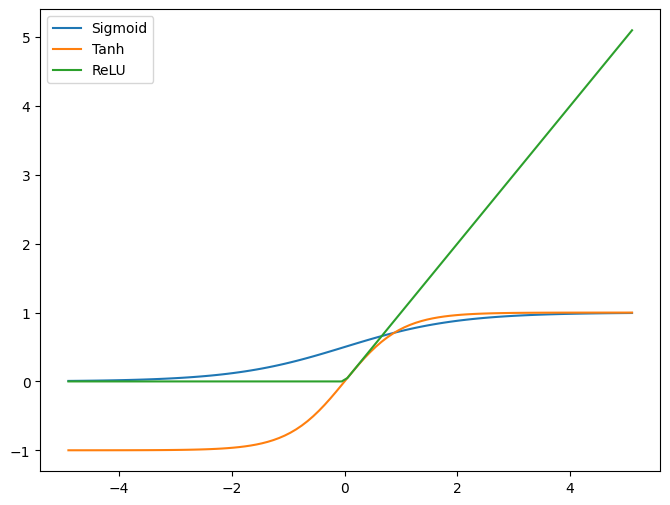

In [11]:
# 위클리 챌린지 5번
# 5. 활성화 함수를 직접 정의하고, 활성화 함수를 적용한 출력을 계산하고, 결과를 그래프로 시각화하세요.

# 입력 값, 가중치, 평향 정의
input_value = np.linspace(-10, 10, 100)
weight = 0.5
bias = 0.1

# 가중 합
weighted_sum = input_value * weight +bias

# 활성화 함수 정의
def sigmoid(x):
  return 1 / (1 + np.exp(-x))

def tanh(x):
  return np.tanh(x)

def relu(x):
  return np.maximum(0, x)

# 활성화 함수 적용
output_sigmoid = sigmoid(weighted_sum)
output_tanh = tanh(weighted_sum)
output_relu = relu(weighted_sum)

# 활성화 함수 출력
print("Sigmoid : ", output_sigmoid)
print("Tanh : ", output_tanh)
print("ReLU : ", output_relu)

plt.figure(figsize=(8,6))

sns.lineplot(x = weighted_sum, y = output_sigmoid, label = 'Sigmoid')
sns.lineplot(x = weighted_sum, y = output_tanh, label = 'Tanh')
sns.lineplot(x = weighted_sum, y = output_relu, label = 'ReLU')


plt.show()

In [11]:
# 위클리 챌린지 6번
# 6. 비선형 데이터셋을 생성하고, MLP(다층 퍼셉트론) 모델을 설계하고 학습시켜 분류를 수행하세요.

# 가상 데이터셋 설정
x, y = make_moons(n_samples = 1000, noise = 0.2, random_state = 42)

# 학습, 테스트 데이터 분리
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state = 42)

# 정규화
scaler = StandardScaler()

x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

# tensor 변환
x_train_tensor = torch.tensor(x_train_scaled, dtype = torch.float32)
y_train_tensor = torch.tensor(y_train, dtype = torch.long)

x_test_tensor = torch.tensor(x_test_scaled, dtype = torch.float32)
y_test_tensor = torch.tensor(y_test, dtype = torch.long)

# DataLoader 생성
train_dataset = TensorDataset(x_train_tensor, y_train_tensor)

train_loader = DataLoader(train_dataset, batch_size = 32, shuffle = True)

# MLP 모델 설계
class MLPModel(nn.Module):
  def __init__(self):
    super().__init__()

    self.fc1 = nn.Linear(2, 32)
    self.fc2 = nn.Linear(32, 32)
    self.fc3 = nn.Linear(32, 2)

  def forward(self, x):
    x = torch.relu(self.fc1(x))
    x = torch.relu(self.fc2(x))
    x = self.fc3(x)
    return x

model = MLPModel()

# 손실함수 및 옵티마이저
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr = 0.01)

# 모델 학습
epochs = 100

for epoch in range(epochs):
  model.train()
  running_loss = 0.0
  for input, label in train_loader:
    optimizer.zero_grad() # 가중치 초기화
    output = model(input)
    loss = criterion(output, label)
    loss.backward()
    optimizer.step()
    running_loss += loss.item()

  if (epoch + 1) % 10 == 0:
    print(f"Epoch {epoch+1}/{epochs}, Loss: {running_loss/len(train_loader)}")



# 모델 평가
model.eval()
correct = 0
total = 0

with torch.no_grad():
    test_outputs = model(x_test_tensor)

    _, predicted = torch.max(test_outputs, 1)


accuracy = accuracy_score(y_test_tensor, predicted.numpy())

print(f"테스트 정확도: {accuracy* 100:.2f}%")

Epoch 10/100, Loss: 0.07404023610055446
Epoch 20/100, Loss: 0.07248924128711223
Epoch 30/100, Loss: 0.06543147064745426
Epoch 40/100, Loss: 0.06520163172855974
Epoch 50/100, Loss: 0.058668792210519315
Epoch 60/100, Loss: 0.059351446107029915
Epoch 70/100, Loss: 0.06467162393033504
Epoch 80/100, Loss: 0.060105065237730744
Epoch 90/100, Loss: 0.060214763898402454
Epoch 100/100, Loss: 0.05708431964740157
테스트 정확도: 98.50%


In [19]:
# 위클리 챌린지 7번
# 7. CNN(Convolutional Neural Network)을 직접 구성하여 이미지 분류를 수행하세요.

# 가상 데이터셋 생성 및 전철
num_classes = 10
input_shape = (32, 32, 3)

# 데이터셋 나누기
x_train = np.random.random((1000, 32, 32, 3)).astype(np.float32)
y_train = np.random.randint(num_classes, size=(1000,))

x_test = np.random.random((200, 32, 32, 3)).astype(np.float32)
y_test = np.random.randint(num_classes, size=(200,))

# 데이터셋 및 데이터 로더 생성
train_dataset = TensorDataset(torch.tensor(x_train).permute(0, 3, 1, 2), torch.tensor(y_train))
test_dataset = TensorDataset(torch.tensor(x_test).permute(0, 3, 1, 2), torch.tensor(y_test))

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

# 모델 정의
class simpleCNN(nn.Module):
  def __init__(self):
    super(simpleCNN, self).__init__()
    self.conv1 = nn.Conv2d(3, 32, kernel_size = 3, padding = 1)
    self.conv2 = nn.Conv2d(32, 64, kernel_size = 3, padding = 1)
    self.conv3 = nn.Conv2d(64, 128, kernel_size = 3, padding = 1)
    self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
    self.flatten = nn.Flatten()
    self.fc1 = nn.Linear(128 * 4 * 4, 128)
    self.fc2 = nn.Linear(128, num_classes)


  def forward(self, x):
    x = torch.relu(self.conv1(x))
    x = self.pool(x)
    x = torch.relu(self.conv2(x))
    x = self.pool(x)
    x = torch.relu(self.conv3(x))
    x = self.pool(x)
    x = self.flatten(x)
    x = torch.relu(self.fc1(x))
    x = self.fc2(x)
    return x

model = simpleCNN()


# 손실 함수 및 옵티마이저
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)


# 모델 학습
num_epochs = 10

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    for inputs, labels in train_loader:
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()

    print(f'Epoch {epoch+1}, Loss: {running_loss/len(train_loader)}')


# 모델 평가
model.eval()
correct = 0
total = 0

with torch.no_grad():
    for inputs, labels in test_loader:
        outputs = model(inputs)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

accuracy = correct / total
print(f'Test Accuracy: {accuracy * 100:.2f}%')



Epoch 1, Loss: 2.3053420335054398
Epoch 2, Loss: 2.300525262951851
Epoch 3, Loss: 2.300634205341339
Epoch 4, Loss: 2.2995922714471817
Epoch 5, Loss: 2.2995807379484177
Epoch 6, Loss: 2.2990490198135376
Epoch 7, Loss: 2.298600524663925
Epoch 8, Loss: 2.2985697239637375
Epoch 9, Loss: 2.298296809196472
Epoch 10, Loss: 2.2975458949804306
Test Accuracy: 10.00%
